# IS 4487 Lab 3

## Outline

Repeat exercises from Lab 2, but with the *SuperStore Retail Orders* dataset
- Loading installed packages
- Inspect data
- Explore plot types

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_03_retailer_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Superstore Data Dictionary

 ORDER VARIABLES:
 - Order ID
 - Order Date
 - Order Year Month - Year and month of the order
 - Order Type - Was the order completed at a store or online? (Retail, Online)
 - Quantity - Quantity ordered for the product

 CUSTOMER VARIABLES:
 - Customer Name
 - City
 - State Province
 - Email

PRODUCT VARIABLES:
 - Product Name
 - Product Line - Category of the product (i.e. Bikes Phones)
 - Product Price - Price in US Dollars
 - Product Status - Current status of the product (Active, Inactive)

## Load Libraries

➡️ Assignment Tasks
- Load any necessary libraries

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
import sklearn as sl
import matplotlib.pyplot as plt


## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the SuperStore retail dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe

In [19]:
df = pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/Labs/DataSets/superstore_retail_orders.csv')
print (df)

df.describe()

       order_id  order_date order_year_month     customer_name  \
0         51188  2023-07-01          2023-07     Audrey Blanco   
1         51187  2023-07-01          2023-07       Isaac Allen   
2         51199  2023-07-02          2023-07        Ian Morgan   
3         51241  2023-07-04          2023-07        Alexa Bell   
4         51297  2023-07-08          2023-07        Casey Diaz   
...         ...         ...              ...               ...   
56038     74084  2024-06-29          2024-06        Ian Rogers   
56039     74062  2024-06-29          2024-06   Marcus Anderson   
56040     74065  2024-06-29          2024-06  Nathaniel Howard   
56041     74038  2024-06-29          2024-06        Robin Sanz   
56042     74110  2024-06-30          2024-06   Mallory Jimenez   

                    city state_province                       email  \
0      North Cherylmouth  New Hampshire     audrey_blanco@email.com   
1             Traceyland  West Virginia       isaac_allen@email.c

,order_id,quantity,product_price
count,56043.000000,56004.000000,56043.000000
mean,61668.410578,3.348582,6198.309433
std,7508.142486,422.654112,35784.965255
min,45079.000000,1.000000,2.290000
25%,55644.500000,1.000000,7.950000
50%,61870.000000,1.000000,475.600000
75%,68097.000000,2.000000,914.620000
max,74147.000000,100000.000000,235481.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56043 non-null  int64  
 1   order_date        56011 non-null  object 
 2   order_year_month  56011 non-null  object 
 3   customer_name     56043 non-null  object 
 4   city              55569 non-null  object 
 5   state_province    55569 non-null  object 
 6   email             56043 non-null  object 
 7   order_type        56043 non-null  object 
 8   quantity          56004 non-null  float64
 9   product_name      56043 non-null  object 
 10  product_line      56043 non-null  object 
 11  product_price     56043 non-null  float64
 12  product_status    56043 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 5.6+ MB


## Prepare Data

➡️ Assignment Tasks
- Create a "revenue" variable and make sure it is a numeric datatype
- Remove rows with empty (NULL) values
- Locate outliers in at least two of the variables.   Filter them out if they are mistakes; keep them if they are exceptional cases.

In [21]:
# revenue variable
df['revenue'] = pd.to_numeric(df['quantity'] * df['product_price'], errors='coerce')
df['revenue']

,revenue
0,1949.97
1,2599.96
2,3249.95
3,649.99
4,649.99
...,...
56038,914.62
56039,914.62
56040,914.62
56041,914.62


In [22]:
# removing rows with null values
df = df.dropna()
df.head()

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status,revenue
0,51188,2023-07-01,2023-07,Audrey Blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,1949.97
1,51187,2023-07-01,2023-07,Isaac Allen,Traceyland,West Virginia,isaac_allen@email.com,Online,4.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,2599.96
2,51199,2023-07-02,2023-07,Ian Morgan,Dylanberg,South Dakota,ian_morgan@email.com,Online,5.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,3249.95
3,51241,2023-07-04,2023-07,Alexa Bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,649.99
4,51297,2023-07-08,2023-07,Casey Diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1.0,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,649.99


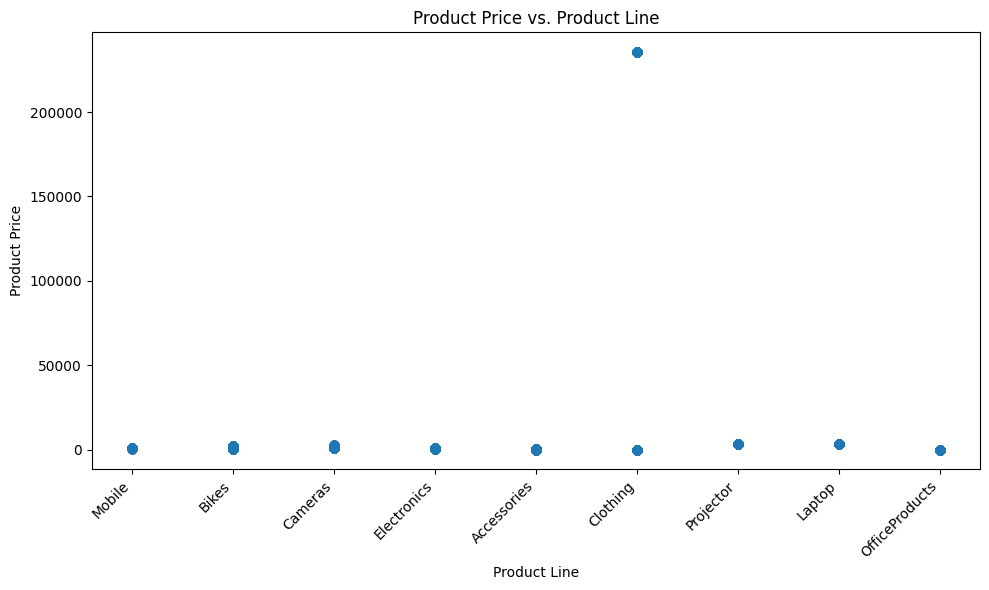

In [23]:
# using scatterchart to identify outliers
plt.figure(figsize=(10, 6))
plt.scatter(df['product_line'], df['product_price'])
plt.xlabel('Product Line')
plt.ylabel('Product Price')
plt.title('Product Price vs. Product Line')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

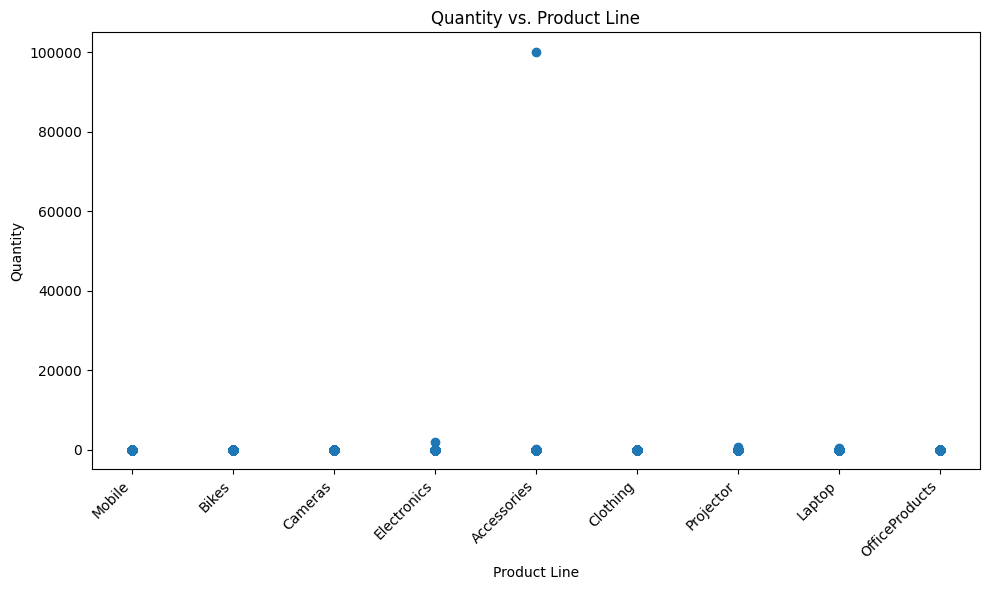

In [24]:
# Another chart to identify outliers
plt.figure(figsize=(10, 6))
plt.scatter(df['product_line'], df['quantity'])
plt.xlabel('Product Line')
plt.ylabel('Quantity')
plt.title('Quantity vs. Product Line')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
 # cleaning up dataset without the outliers
 clean_df = df[(df['product_price'] < 15000) & (df['quantity'] < 100.0)]
 clean_df.describe()

,order_id,quantity,product_price,revenue
count,54166.000000,54166.000000,54166.000000,54166.000000
mean,61643.233911,1.490418,616.595279,689.223301
std,7518.038701,0.615210,817.132239,906.612413
min,45079.000000,1.000000,2.290000,2.290000
25%,55624.000000,1.000000,7.950000,14.970000
50%,61856.000000,1.000000,475.600000,475.600000
75%,68063.000000,2.000000,914.620000,1000.440000
max,74147.000000,20.000000,3578.270000,71565.400000


## Summarize Data

➡️ Assignment Tasks
- Display the average price per product line
- Display the total revenue for all months

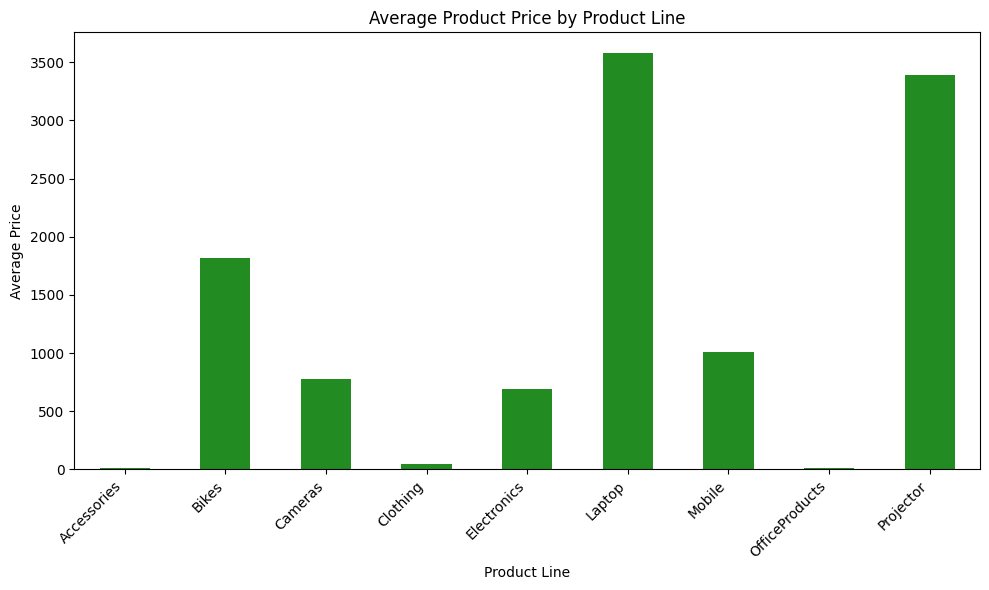

In [26]:
# average price
avg_price_by_line = clean_df.groupby('product_line')['product_price'].mean()
avg_price_by_line.plot(kind='bar', figsize=(10, 6), color ='forestgreen')
plt.title('Average Product Price by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

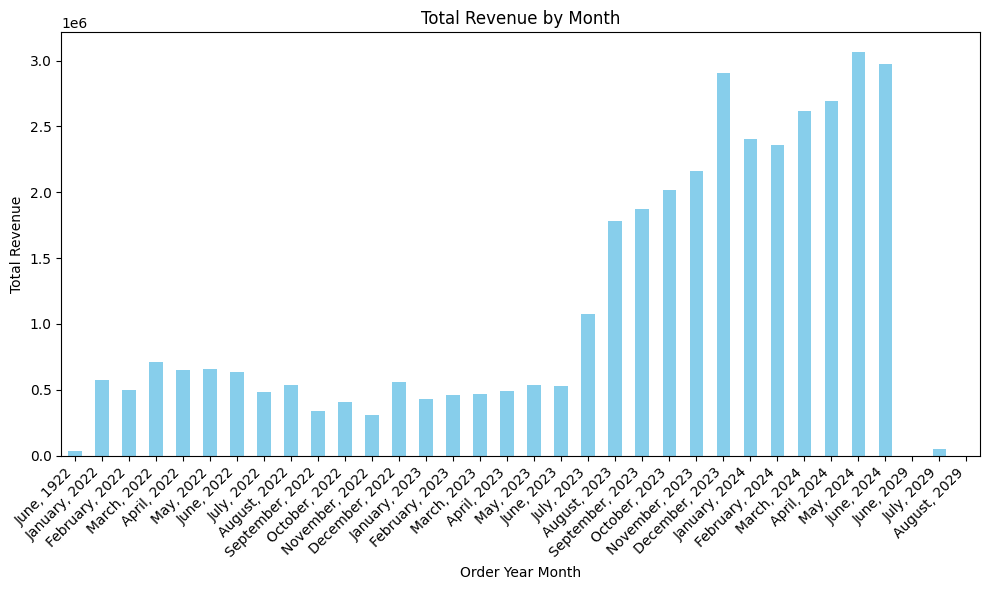

In [27]:
#total revenue
total_revenue_by_month = clean_df.groupby('order_year_month')['revenue'].sum()
total_revenue_by_month.index = pd.to_datetime(total_revenue_by_month.index, format='%Y-%m', errors='coerce')
total_revenue_by_month = total_revenue_by_month[total_revenue_by_month.index.notnull()]
total_revenue_by_month.index = total_revenue_by_month.index.strftime('%B, %Y')
total_revenue_by_month.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Total Revenue by Month')
plt.xlabel('Order Year Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Obviously, the June, 1922 and the August, 2029 entries are outliers and I acknowledge that but since I was not asked to clean for a third outlier, I will leave it as is.

In [30]:
!ls "/content/drive/My Drive/Colab Notebooks/Buss. Analytics/"

lab_02_megatelco_intro.ipynb  lab1_python_intro-2.html	 lab1_python_intro.ipynb  lab2-2.ipynb
lab_03_retailer_intro.ipynb   lab1_python_intro-2.ipynb  lab2-2.html		  lab2.ipynb


In [33]:
!jupyter nbconvert --to html "/content/drive/My Drive/Colab Notebooks/Buss. Analytics/lab_03_retailer_intro.ipynb"

[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/Buss. Analytics/lab_03_retailer_intro.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 550549 bytes to /content/drive/My Drive/Colab Notebooks/Buss. Analytics/lab_03_retailer_intro.html
